# Catatan!

seluruh syntax di file ini ditulis oleh satu orang, Ananda salwa pratama (2313020125)

# Importing library

In [1]:
import pandas as pd

In [2]:
import os

size = os.path.getsize("../datasets/project1/US_Accidents_March23.csv")
print(f"{size / 1024**3:.2f} GB")

2.85 GB


# Load dataset

In [3]:
import pandas as pd
import numpy as np

# Hitung total baris mentah dulu (opsional, misal kita tahu ada 7 juta)
total_rows = 7000000
sample_size = 500000

# Buat fungsi untuk menentukan baris mana saja yang mau di-skip secara acak
# Baris indeks 0 (header) HARUS tetap di-load (tidak boleh di-skip)
skip_indices = np.random.choice(
    np.arange(1, total_rows),
    size=total_rows - sample_size,
    replace=False
)
# Ubah ke bentuk set agar proses pencarian saat loading jauh lebih cepat
skip_indices_set = set(skip_indices)

# Load data dengan skip baris yang terpilih acak
df = pd.read_csv('../datasets/project1/US_Accidents_March23.csv', skiprows=lambda x: x in skip_indices_set)

print(df.shape) # Hasilnya bakal sekitar 500.000 baris acak

(1228394, 46)


In [4]:
# Reset index untuk memunculkan penomoran otomatis dari 0
df_info = df.dtypes.reset_index()

# Ganti nama kolomnya biar lebih rapi dan jelas
df_info.columns = ['Nama Kolom', 'Tipe Data']

# Tampilkan hasilnya
df_info

,Nama Kolom,Tipe Data
0,ID,str
1,Source,str
2,Severity,int64
3,Start_Time,str
4,End_Time,str
5,Start_Lat,float64
6,Start_Lng,float64
7,End_Lat,float64
8,End_Lng,float64
9,Distance(mi),float64


## 2. Informasi dataset

In [5]:
print("Informasi dataset")
print(df.describe())

Informasi dataset
           Severity     Start_Lat     Start_Lng        End_Lat        End_Lng  \
count  1.228394e+06  1.228394e+06  1.228394e+06  985288.000000  985288.000000   
mean   2.270457e+00  3.706248e+01 -9.892150e+01      37.290290    -100.294158   
std    6.063468e-01  5.012499e+00  1.840448e+01       5.034115      18.627975   
min    1.000000e+00  2.456603e+01 -1.244976e+02      24.566013    -124.497829   
25%    2.000000e+00  3.388202e+01 -1.182252e+02      33.933950    -118.361306   
50%    2.000000e+00  3.740087e+01 -9.534397e+01      37.641071     -96.917190   
75%    2.000000e+00  4.073974e+01 -8.136838e+01      40.822320     -81.483107   
max    4.000000e+00  4.900220e+01 -6.740355e+01      49.002140     -67.403550   

       Distance(mi)  Temperature(F)  Wind_Chill(F)   Humidity(%)  \
count  1.228394e+06    1.199344e+06  877125.000000  1.197893e+06   
mean   5.049544e-01    6.052625e+01      56.787700  6.376950e+01   
std    1.686201e+00    1.889151e+01      22.3196

Keterangan label, tujuan prediksi yaitu memprediksi tingkat keparahan kecelakaan nilainya mulai dari 1 - 4 

kita deskripsikan sendiri 

1. tidak parah
2. sedang 
3. parah 
4. sangat parah

In [6]:
label = df['Severity']

print(label.unique())

[3 2 1 4]


## 3. Pengecekkan missing value 

In [7]:
print('# Jumlah missing value asli')
missing_ori = df.isnull().sum()
total_baris = len(df) # 1. Hitung total baris dataset kamu (7 juta data)

tabel_data_miss = []
no = 0
for var, val in missing_ori.items():
    if val > 0:
        tipe_data = df[var].dtype

        unique_val = df[var].dropna().unique()
        num_unique = len(unique_val)

        # 2. Rumus persentase yang benar: (jumlah missing / total baris) * 100
        val_in_percentage = (val / total_baris) * 100

        if num_unique < 5:
            isi_tampilan = str(list(unique_val))
        else:
            isi_tampilan = f"{list(unique_val[:3])} "

        tabel_data_miss.append({
            "Nama kolom": var,
            "Tipe Data": str(tipe_data),
            'Jumlah Missing value': val,
            "Sampel / Isi Unik": isi_tampilan,
            "Total Unique": num_unique,
            "Persentase (%)": round(val_in_percentage, 4) # 3. Dibulatkan 4 angka biar rapi di API Next.js
        })

df_missing_report = pd.DataFrame(tabel_data_miss)
df_missing_report

# Jumlah missing value asli


,Nama kolom,Tipe Data,Jumlah Missing value,Sampel / Isi Unik,Total Unique,Persentase (%)
0,End_Lat,float64,243106,"[np.float64(40.01228), np.float64(39.00263), n...",471124,19.7906
1,End_Lng,float64,243106,"[np.float64(-82.99218), np.float64(-80.2264699...",478599,19.7906
2,Street,str,808,"['I-70 E', 'Sportsman Club Rd', 'Miamisburg Ce...",112185,0.0658
3,City,str,54,"['Dayton', 'Johnstown', 'Waynesville']",10987,0.0044
4,Zipcode,str,641,"['45424', '43031-9133', '45449']",188881,0.0522
5,Timezone,str,1973,"['US/Eastern', 'US/Pacific', 'US/Central', 'US...",4,0.1606
6,Airport_Code,str,3523,"['KFFO', 'KCMH', 'KMGY']",1991,0.2868
7,Weather_Timestamp,str,20193,"['2016-02-08 05:58:00', '2016-02-08 12:51:00',...",395992,1.6439
8,Temperature(F),float64,29050,"[np.float64(36.9), np.float64(37.9), np.float6...",784,2.3649
9,Wind_Chill(F),float64,351269,"[np.float64(34.4), np.float64(10.6), np.float6...",904,28.5958


Nilai missing value tertinggi yakni di variabel 

1. End_Lat = 44.03%
2. End_lng = 44.03%

In [8]:
# 1. Hitung persentase seperti biasa (ini masih berupa Series yang punya nama kolom)
missing_percentage_max = df.isnull().mean() * 100

# 2. Cari tahu nama kolom yang nilainya paling tinggi
kolom_tertinggi = missing_percentage_max.idxmax()

# 3. Ambil nilai persentase dari kolom tertinggi tersebut
nilai_tertinggi = missing_percentage_max.max()

print(f"Kolom paling kotor: {kolom_tertinggi}")
print(f"Persentase Missing : {nilai_tertinggi:.2f}%")

Kolom paling kotor: Precipitation(in)
Persentase Missing : 33.21%


Catatan penanganan missing value dan terdapat 21 kolom missing value disini anjir : 

1. End_Lat dan  : drop
2. Street : modus
3. City : modus 
4. zip-code : modus
5. Time-zone : Modus
6. Airport-Code : modus
7. Wheater_Timestamp : modus
8. Temperatur : median
9. wind_Chil : median
10. Humidity : median 
11. Pressure : median
12. visibilty : median 
13. wind_direction : modus
14. wind_speed : median
15. precipitation : modus
16. Weather_condition : modus
17. Sunrise_sunset : modus
18. Civil_Twilight : modus
19. Nautical_Twilight : modus 
20. Astronomical_Twilight : modus
21. End_lng : drop


In [9]:
import pandas as pd

# Pastikan df adalah data yang sedang kamu olah (misal df_sample kamu)
df_clean = df.copy()

# ==========================================
# 1. TAHAP DROP BARIS (Koordinat)
# ==========================================
kolom_drop = ['End_Lat', 'End_Lng']
df_clean = df_clean.dropna(subset=kolom_drop)


# ==========================================
# 2. TAHAP IMPUTASI MODUS (Kategorikal & Kasus Khusus)
# ==========================================
kolom_modus = [
    'Street', 'City', 'Zipcode', 'Timezone', 'Airport_Code',
    'Weather_Timestamp', 'Wind_Direction', 'Precipitation(in)',
    'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight'
]

for col in kolom_modus:
    # Cek dulu apakah kolomnya ada di dataframe (menghindari typo/error nama kolom)
    if col in df_clean.columns:
        # Ambil nilai modus pertama [0], jika kolom kosong sama sekali gunakan fallback 'Unknown'
        modus_val = df_clean[col].mode()
        fill_val = modus_val[0] if not modus_val.empty else 'Unknown'

        df_clean[col] = df_clean[col].fillna(fill_val)


# ==========================================
# 3. TAHAP IMPUTASI MEDIAN (Numerik Ber-Outlier)
# ==========================================
kolom_median = [
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)'
]

for col in kolom_median:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# ==========================================
# 4. VALIDASI AKHIR (Cek apakah sudah bersih)
# ==========================================
sisa_missing = df_clean.isnull().sum().sum()
print(f"Proses Selesai! Sisa total missing value di dataset: {sisa_missing}")

Proses Selesai! Sisa total missing value di dataset: 0


Cek ulang untuk memastikan data benar benar bersih dari missing value 

In [10]:
df_clean.isnull().sum()

ID                       0
Source                   0
Severity                 0
Start_Time               0
End_Time                 0
Start_Lat                0
Start_Lng                0
End_Lat                  0
End_Lng                  0
Distance(mi)             0
Description              0
Street                   0
City                     0
County                   0
State                    0
Zipcode                  0
Country                  0
Timezone                 0
Airport_Code             0
Weather_Timestamp        0
Temperature(F)           0
Wind_Chill(F)            0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
S

## 4. Pengecekkan Outliers

Data yang terdapat missing value dan terdapat outliers juga  

1. Temperatur = 2% missing values
2. Wind chil 25% =  missing values
4. Pressure(in) =  1% 
5. Visibility (mi) =  2.3% missing values 
6. Wind_speed (mph) = 7% missing values
7. Precipitation = 28% missing values 

In [11]:
# Pengambilan kolom dengan isi / nilai numerik
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).drop(columns=['Severity'])

# Hitung Q1, Q3, dan IQR

Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

#  Filter outlier
outliers = ((num_cols < (Q1 - 1.5 * IQR)) | (num_cols > (Q3 + 1.5 * IQR)))

total_outlier = outliers.sum()


print(total_outlier[total_outlier > 0])

Distance(mi)          94164
Temperature(F)         7157
Wind_Chill(F)         68388
Pressure(in)          72505
Visibility(mi)       195358
Wind_Speed(mph)       40784
Precipitation(in)     73525
dtype: int64


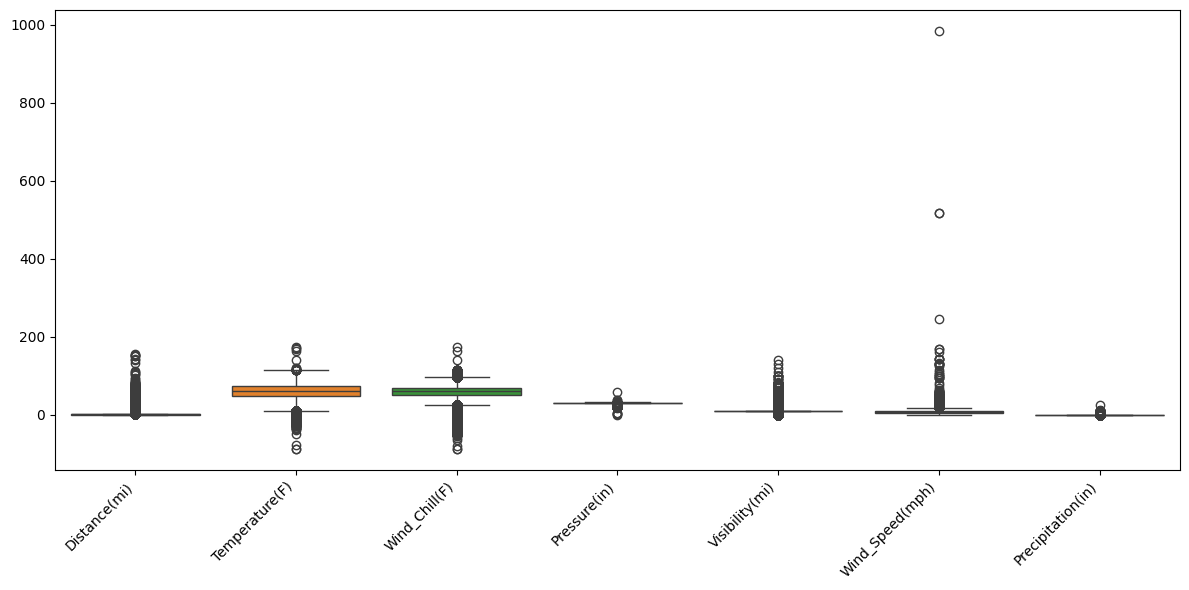

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_outlier = total_outlier[total_outlier > 0].index

plt.figure(figsize=(12, 6))
sns.boxplot(data=num_cols[kolom_outlier])
plt.xticks(rotation=45, ha='right')  # ha='right' biar teksnya pas di bawah garis tick
plt.tight_layout()                  # Biar gak ada teks yang kepotong di pinggir grafik
plt.show()


# 5. Sekarang penanganan outliers 

1. Distance : capping
2. temperatur : caping 
3. Windchill : capping
4. Pressure : capping 
5. Visibility : capping 
6. wind_speed : capping 
7. Precipitation : capping

Penanganan menggunakan capping

In [13]:
import numpy as np


# Pastikan df_clean adalah kelanjutan dari data yang sudah bersih missing value-nya
df_no_outliers = df_clean.copy()

# List kolom numerik yang mau kamu lakukan capping sesuai catatanmu
kolom_capping = [
    'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

print("=== Memulai Proses Capping Outliers ===")

for col in kolom_capping:
    if col in df_no_outliers.columns:
        # 1. Hitung Q1, Q3, dan IQR untuk kolom saat ini
        Q1 = df_no_outliers[col].quantile(0.25)
        Q3 = df_no_outliers[col].quantile(0.75)
        IQR = Q3 - Q1

        # 2. Tentukan Batas Atas dan Batas Bawah
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 3. Eksekusi Capping menggunakan np.clip
        # Fungsi ini otomatis mengubah nilai di luar batas menjadi nilai batas tersebut
        df_no_outliers[col] = np.clip(df_no_outliers[col], lower_bound, upper_bound)

        print(f"✔️ Kolom {col:<18} | Batas Bawah: {lower_bound:<8.2f} | Batas Atas: {upper_bound:.2f}")

print("\nProses Capping Selesai! Sekarang semua data ekstrem sudah rapi.")

=== Memulai Proses Capping Outliers ===
✔️ Kolom Distance(mi)       | Batas Bawah: -0.85    | Batas Atas: 1.42
✔️ Kolom Temperature(F)     | Batas Bawah: 9.00     | Batas Atas: 113.00
✔️ Kolom Wind_Chill(F)      | Batas Bawah: 24.00    | Batas Atas: 96.00
✔️ Kolom Pressure(in)       | Batas Bawah: 28.35    | Batas Atas: 31.04
✔️ Kolom Visibility(mi)     | Batas Bawah: 10.00    | Batas Atas: 10.00
✔️ Kolom Wind_Speed(mph)    | Batas Bawah: -2.50    | Batas Atas: 17.50
✔️ Kolom Precipitation(in)  | Batas Bawah: 0.00     | Batas Atas: 0.00

Proses Capping Selesai! Sekarang semua data ekstrem sudah rapi.


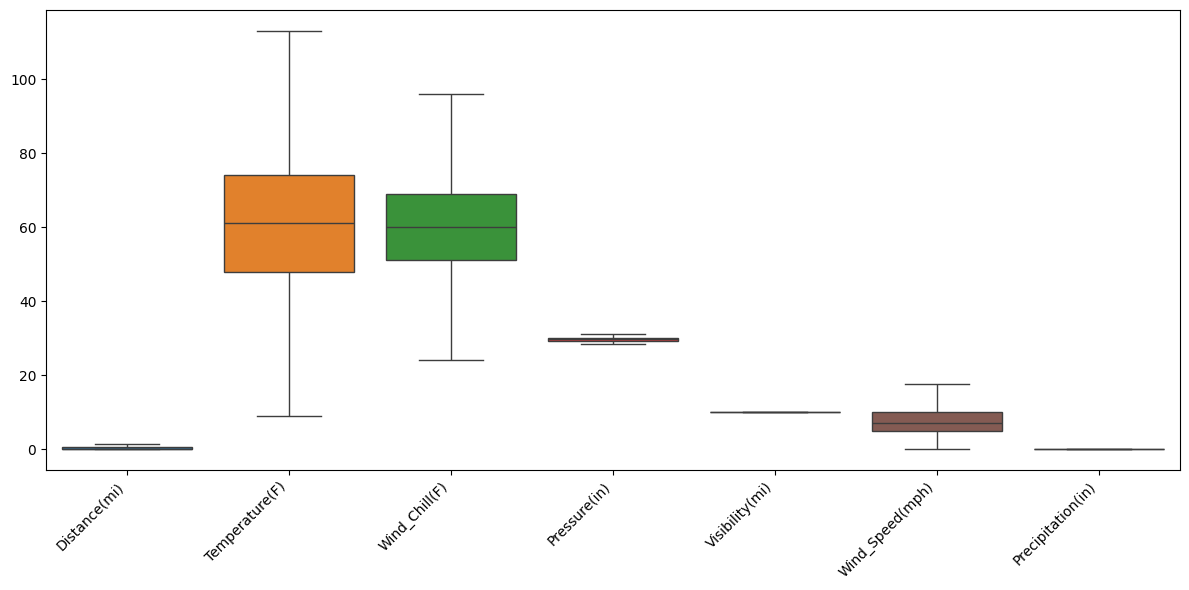

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_no_outliers[kolom_outlier])
plt.xticks(rotation=45, ha='right')  # ha='right' biar teksnya pas di bawah garis tick
plt.tight_layout()                  # Biar gak ada teks yang kepotong di pinggir grafik
plt.show()

# 6. Transformasi & endcoding

Encoding 

In [15]:
# 1. Ambil kolom yang bertipe teks/kategorikal saja
df_str = df.select_dtypes(include=['object', 'string'])

tabel_data_str = []

# 2. Looping untuk mengambil informasi setiap kolom str
for col in df_str.columns:
    # Ambil nilai unik (dropna() agar missing value tidak dihitung sebagai nilai unik)
    unique_val = df[col].dropna().unique()
    num_unique = len(unique_val)

    # Kondisi tampilan sampel isi unik biar ringkas dan gak menuhin tabel
    if num_unique < 5:
        isi_tampilan = str(list(unique_val))
    else:
        isi_tampilan = f"{list(unique_val[:3])} ... (+ total {num_unique} unik)"

    # Masukkan data ke dalam list berupa dictionary
    tabel_data_str.append({
        "Nama kolom": col,
        "Tipe Data": "str",
        "Total Unique": num_unique,
        "Sampel / Isi Unik": isi_tampilan
    })

# 3. Ubah ke DataFrame baru agar otomatis jadi tabel interaktif
df_str_report = pd.DataFrame(tabel_data_str)

# 4. Tampilkan hasilnya
df_str_report

,Nama kolom,Tipe Data,Total Unique,Sampel / Isi Unik
0,ID,str,1228394,"['A-1', 'A-26', 'A-55'] ... (+ total 1228394 u..."
1,Source,str,3,"['Source2', 'Source3', 'Source1']"
2,Start_Time,str,1050631,"['2016-02-08 05:46:00', '2016-02-08 12:41:08',..."
3,End_Time,str,1107610,"['2016-02-08 11:00:00', '2016-02-08 13:11:08',..."
4,Description,str,620536,['Right lane blocked due to accident on I-70 E...
5,Street,str,112185,"['I-70 E', 'Sportsman Club Rd', 'Miamisburg Ce..."
6,City,str,10987,"['Dayton', 'Johnstown', 'Waynesville'] ... (+ ..."
7,County,str,1737,"['Montgomery', 'Licking', 'Warren'] ... (+ tot..."
8,State,str,49,"['OH', 'CA', 'FL'] ... (+ total 49 unik)"
9,Zipcode,str,188881,"['45424', '43031-9133', '45449'] ... (+ total ..."


In [16]:
import pandas as pd
from category_encoders import TargetEncoder

# Pastikan df_no_outliers adalah dataframe lu yang udah beres tahap capping outlier
df_transformed = df_no_outliers.copy()

print("=== 1. TAHAP DROP KOLOM STRING YANG TIDAK DIPERLUKAN ===")
# Weather_Timestamp kita drop sekalian karena isinya waktu yang terlalu spesifik (396rb unik)
# Kalau dipaksa masuk One-Hot Encoding, RAM laptop dijamin langsung meledak, bro!
kolom_to_drop = ['ID', 'Description', 'Weather_Timestamp', "Country"]
df_transformed = df_transformed.drop(columns=kolom_to_drop, errors='ignore')
print(f"✔️ Kolom {kolom_to_drop} berhasil dihapus.")


print("\n=== 2. TAHAP TARGET ENCODING (HIGH CARDINALITY) ===")
# Menentukan target/label variabel lu (asumsi utama: 'Severity')
target_col = 'Severity'

# Kolom-kolom string dengan jumlah nilai unik yang sangat banyak (High Cardinality)
# Di sinilah keajaiban Target Encoding bekerja: merubah nama teks jadi angka bobot risiko
kolom_target_encode = ['City', 'Street', 'Zipcode', 'Weather_Condition', 'Airport_Code', "County"]

# smoothing=10.0 membantu menstabilkan bobot kota/jalan yang datanya cuma muncul sedikit
te_encoder = TargetEncoder(cols=kolom_target_encode, smoothing=10.0)

# Proses kalkulasi dan transformasi teks menjadi angka nilai rata-rata target
df_transformed[kolom_target_encode] = te_encoder.fit_transform(
    df_transformed[kolom_target_encode],
    df_transformed[target_col]
)
print(f"✔️ Target Encoding sukses untuk kolom: {kolom_target_encode}")


print("\n=== 3. TAHAP ONE-HOT ENCODING (LOW CARDINALITY) ===")
# Kolom string sisa yang jumlah nilai uniknya dikit (Aman di-One-Hot)
# Airport_Code dan Weather_Timestamp SUDAH DIHAPUS dari list ini agar tidak bentrok
kolom_one_hot = [
    'Source', 'Timezone', 'Wind_Direction',
    'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'State'
]

# Kita pilah kolom one_hot yang benar-benar ada di dataframe saja
kolom_one_hot_ada = [col for col in kolom_one_hot if col in df_transformed.columns]

# Pakai pd.get_dummies, drop_first=True biar gak kena jebakan multikolinieritas
df_transformed = pd.get_dummies(df_transformed, columns=kolom_one_hot_ada, drop_first=True)
print(f"✔️ One-Hot Encoding sukses untuk kolom sisa.")


print("\n=== 4. VALIDASI HASIL TRANSFORMASI ===")
# Memastikan sudah TIDAK ADA LAGI data bertipe object / string (semua harus angka)
sisa_kolom_teks = df_transformed.select_dtypes(include=['object', 'string']).columns

if len(sisa_kolom_teks) == 0:
    print("🔥 MANTAP! Semua kolom string berhasil diringkas dan dikonversi menjadi angka.")
else:
    print(f"⚠️ Perhatian! Masih ada kolom string yang ketinggalan: {list(sisa_kolom_teks)}")

# Tampilkan 5 baris teratas data hasil encoding untuk kamu analisis
df_transformed.head()

=== 1. TAHAP DROP KOLOM STRING YANG TIDAK DIPERLUKAN ===
✔️ Kolom ['ID', 'Description', 'Weather_Timestamp', 'Country'] berhasil dihapus.

=== 2. TAHAP TARGET ENCODING (HIGH CARDINALITY) ===
✔️ Target Encoding sukses untuk kolom: ['City', 'Street', 'Zipcode', 'Weather_Condition', 'Airport_Code', 'County']

=== 3. TAHAP ONE-HOT ENCODING (LOW CARDINALITY) ===
✔️ One-Hot Encoding sukses untuk kolom sisa.

=== 4. VALIDASI HASIL TRANSFORMASI ===
⚠️ Perhatian! Masih ada kolom string yang ketinggalan: ['Start_Time', 'End_Time']


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Street,City,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
243106,3,2016-02-08 20:13:22,2016-02-09 02:13:22,40.02664,-82.99440,40.01228,-82.99218,0.999,2.401572,2.450303,...,False,False,False,False,False,False,False,False,False,False
243107,2,2016-02-10 11:09:08,2016-02-10 17:09:08,38.96943,-80.10960,39.00263,-80.22647,1.415,2.867587,2.219315,...,False,False,False,False,False,False,False,False,True,False
243108,2,2016-02-10 12:54:39,2016-02-10 18:54:39,41.48339,-81.66297,41.47692,-81.66075,0.462,2.290241,2.237312,...,False,False,False,False,False,False,False,False,False,False
243109,2,2016-02-10 21:05:16,2016-02-11 03:05:16,41.47487,-81.72095,41.47442,-81.71182,0.474,2.396488,2.237312,...,False,False,False,False,False,False,False,False,False,False
243110,2,2016-02-11 13:25:43,2016-02-11 19:25:43,41.25666,-81.63157,41.25666,-81.63157,0.000,2.271973,2.190678,...,False,False,False,False,False,False,False,False,False,False


In [17]:
# 1. Ambil kolom yang bertipe teks/kategorikal saja
df_str = df_transformed.select_dtypes(include=['object', 'string'])

tabel_data_str = []

# 2. Looping untuk mengambil informasi setiap kolom str
for col in df_str.columns:
    # Ambil nilai unik (dropna() agar missing value tidak dihitung sebagai nilai unik)
    unique_val = df[col].dropna().unique()
    num_unique = len(unique_val)

    # Kondisi tampilan sampel isi unik biar ringkas dan gak menuhin tabel
    if num_unique < 5:
        isi_tampilan = str(list(unique_val))
    else:
        isi_tampilan = f"{list(unique_val[:3])} ... (+ total {num_unique} unik)"

    # Masukkan data ke dalam list berupa dictionary
    tabel_data_str.append({
        "Nama kolom": col,
        "Tipe Data": "str",
        "Total Unique": num_unique,
        "Sampel / Isi Unik": isi_tampilan
    })

# 3. Ubah ke DataFrame baru agar otomatis jadi tabel interaktif
df_str_report = pd.DataFrame(tabel_data_str)

# 4. Tampilkan hasilnya
df_str_report

,Nama kolom,Tipe Data,Total Unique,Sampel / Isi Unik
0,Start_Time,str,1050631,"['2016-02-08 05:46:00', '2016-02-08 12:41:08',..."
1,End_Time,str,1107610,"['2016-02-08 11:00:00', '2016-02-08 13:11:08',..."


Dilihat dari sisa data yang terdapat  string ini di variabel country hanya 1 unik ini dapat kita drop guys kolomnya

Namanya juga US accident ini di neaga united state doang jadi ngg mungkin ada indonesia dan ini tidak berpengaruh terhadap prediksi okeyy maka kita bisa menghapusnya

In [18]:
print("=== TAHAP FEATURE ENGINEERING (EKSTRAKSI WAKTU) ===")

# 1. Konversi tipe data string menjadi datetime dengan tambahan format='mixed'
df_transformed['Start_Time'] = pd.to_datetime(df_transformed['Start_Time'], format='mixed')
df_transformed['End_Time'] = pd.to_datetime(df_transformed['End_Time'], format='mixed')

# 2. Ekstrak informasi krusial dari waktu mulai kecelakaan (Start_Time)
df_transformed['Start_Hour'] = df_transformed['Start_Time'].dt.hour
df_transformed['Start_Month'] = df_transformed['Start_Time'].dt.month
df_transformed['Day_Of_Week'] = df_transformed['Start_Time'].dt.dayofweek  # 0=Senin, 6=Minggu

# 3. Hitung durasi kecelakaan (selisih End_Time dan Start_Time) dalam hitungan menit
durasi = df_transformed['End_Time'] - df_transformed['Start_Time']
df_transformed['Duration_Minutes'] = durasi.dt.total_seconds() / 60.0

# 4. Drop kolom Start_Time dan End_Time yang asli karena informasinya sudah diekstrak
df_transformed = df_transformed.drop(columns=['Start_Time', 'End_Time'])

print("✔️ Fitur Jam, Bulan, Hari, dan Durasi berhasil diekstrak.")
print(f"Sisa kolom sekarang: {df_transformed.shape[1]}")


=== TAHAP FEATURE ENGINEERING (EKSTRAKSI WAKTU) ===
✔️ Fitur Jam, Bulan, Hari, dan Durasi berhasil diekstrak.
Sisa kolom sekarang: 114


In [19]:
# Reset index untuk memunculkan penomoran otomatis dari 0
df_info = df_transformed.dtypes.reset_index()

# Ganti nama kolomnya biar lebih rapi dan jelas
df_info.columns = ['Nama Kolom', 'Tipe Data']

# Tampilkan hasilnya
df_info

,Nama Kolom,Tipe Data
0,Severity,int64
1,Start_Lat,float64
2,Start_Lng,float64
3,End_Lat,float64
4,End_Lng,float64
...,...,...
109,State_WY,bool
110,Start_Hour,int32
111,Start_Month,int32
112,Day_Of_Week,int32


Hasilnya jadi 114 kolom bjir!!
ini karena one hot encoding dari variabel state dan wind direction

1. state menhasilkan kolom baru kekanan sebanyak jumlah unik dari valuenya yaitu sebanyak : 48  kolom 
2. Wind direction menghasilkan kolom baru sebanyakn: 23 kolom
3. dan ada yang di drop yaitu id , description, country, Wheater_time stamp
4. jadi total kolom saat ini adalah 
   state = 48 kolom 
   wind direction = 23 kolom
   sisa kolom = 42 (just feature)
   total kolom = state + wind direction + sisa kolom + kolom target
               = 48 + 23 + 42  + 1 
               = 114 kolom!

Saya bingung sebagai pemula data scientist brang kaya gini tuh bikin ribet kolomnya makin banyak tapi ini kata gemini malah makin bagus ini data bersih dan standart industry, karena aku belum memiliki pengalaman di industry maka disini aku ngikut aja ngikutin aja gimana maunya gemini okeyyy.

ditulis oleh : Ananda salwa pratama (2313020125)

In [20]:
# 1. Set agar Pandas menampilkan semua kolom tanpa batas ke samping
pd.set_option('display.max_columns', None)

# 2. Set agar teks di dalam kolom gak kepotong kalau kepanjangan (opsional)
pd.set_option('display.max_colwidth', None)

# 3. Panggil ulang data lu buat dicek horizontal
df_transformed.head()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Street,City,County,Zipcode,Airport_Code,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Timezone_US/Eastern,Timezone_US/Mountain,Timezone_US/Pacific,Wind_Direction_Calm,Wind_Direction_E,Wind_Direction_ENE,Wind_Direction_ESE,Wind_Direction_East,Wind_Direction_N,Wind_Direction_NE,Wind_Direction_NNE,Wind_Direction_NNW,Wind_Direction_NW,Wind_Direction_North,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SSE,Wind_Direction_SSW,Wind_Direction_SW,Wind_Direction_South,Wind_Direction_VAR,Wind_Direction_Variable,Wind_Direction_W,Wind_Direction_WNW,Wind_Direction_WSW,Wind_Direction_West,Sunrise_Sunset_Night,Civil_Twilight_Night,Nautical_Twilight_Night,Astronomical_Twilight_Night,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Start_Hour,Start_Month,Day_Of_Week,Duration_Minutes
243106,3,40.02664,-82.99440,40.01228,-82.99218,0.999,2.401572,2.450303,2.498628,2.542181,2.385504,33.8,27.0,100.0,29.63,10.0,8.1,0.0,2.333053,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,20,2,0,360.0
243107,2,38.96943,-80.10960,39.00263,-80.22647,1.415,2.867587,2.219315,2.323214,2.219315,2.440739,15.8,60.0,79.0,29.87,10.0,7.0,0.0,2.333053,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,11,2,2,360.0
243108,2,41.48339,-81.66297,41.47692,-81.66075,0.462,2.290241,2.237312,2.179487,2.287215,2.227859,24.1,24.0,75.0,29.82,10.0,17.5,0.0,2.333053,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,12,2,2,360.0
243109,2,41.47487,-81.72095,41.47442,-81.71182,0.474,2.396488,2.237312,2.179487,2.347971,2.227859,21.9,24.0,68.0,29.92,10.0,17.5,0.0,2.333053,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# 1. PISAHKAN FITUR (X) DAN TARGET (y)
X = df_transformed.drop(columns=['Severity'])
y = df_transformed['Severity'].reset_index(drop=True)

print(f"Bentuk data awal: {X.shape[0]} baris, {X.shape[1]} fitur/kolom.")

# 2. LAKUKAN TRAIN-TEST SPLIT DULU (Mencegah Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data Training: {X_train.shape[0]} baris | Data Testing: {X_test.shape[0]} baris")

print("\n=== TAHAP 1: STANDARISASI DATA (STANDARD SCALING) ===")
scaler = StandardScaler()
# FIT HANYA DI X_TRAIN, TRANSFORM DI X_TRAIN DAN X_TEST
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✔️ Standarisasi Selesai! Skala fitur sudah disesuaikan tanpa leakage.")

print("\n=== TAHAP 2: PRINCIPAL COMPONENT ANALYSIS (PCA) - (Untuk Catatan/Analisa) ===")
# PCA untuk melihat informasi (varians) pada data training
pca = PCA()
X_pca_train = pca.fit_transform(X_train_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("\n=== HASIL ANALISIS PCA ===")
for i in range(min(10, len(cumulative_variance))):
    print(f"💡 PC {i+1:<2} mampu mewakili {pca.explained_variance_ratio_[i]*100:<5.2f}% informasi | Total Akumulasi: {cumulative_variance[i]*100:.2f}%")

n_komponen_pilihan = 5
kolom_pc = [f'PC_{i+1}' for i in range(n_komponen_pilihan)]

df_pca_final = pd.DataFrame(X_pca_train[:, :n_komponen_pilihan], columns=kolom_pc)
df_pca_final['Severity'] = y_train.reset_index(drop=True)

print(f"\n🔥 Data PCA dengan {n_komponen_pilihan} komponen (Catatan Saja):")
display(df_pca_final.head())

Bentuk data awal: 985288 baris, 113 fitur/kolom.
Data Training: 788230 baris | Data Testing: 197058 baris

=== TAHAP 1: STANDARISASI DATA (STANDARD SCALING) ===
✔️ Standarisasi Selesai! Skala fitur sudah disesuaikan tanpa leakage.

=== TAHAP 2: PRINCIPAL COMPONENT ANALYSIS (PCA) - (Untuk Catatan/Analisa) ===

=== HASIL ANALISIS PCA ===
💡 PC 1  mampu mewakili 6.49 % informasi | Total Akumulasi: 6.49%
💡 PC 2  mampu mewakili 4.01 % informasi | Total Akumulasi: 10.50%
💡 PC 3  mampu mewakili 3.11 % informasi | Total Akumulasi: 13.61%
💡 PC 4  mampu mewakili 2.30 % informasi | Total Akumulasi: 15.91%
💡 PC 5  mampu mewakili 2.23 % informasi | Total Akumulasi: 18.14%
💡 PC 6  mampu mewakili 1.73 % informasi | Total Akumulasi: 19.87%
💡 PC 7  mampu mewakili 1.61 % informasi | Total Akumulasi: 21.48%
💡 PC 8  mampu mewakili 1.52 % informasi | Total Akumulasi: 22.99%
💡 PC 9  mampu mewakili 1.38 % informasi | Total Akumulasi: 24.38%
💡 PC 10 mampu mewakili 1.29 % informasi | Total Akumulasi: 25.67%

🔥 

,PC_1,PC_2,PC_3,PC_4,PC_5,Severity
0,0.685431,1.977147,3.204674,-1.205619,-0.423625,2
1,-3.442109,2.121498,-0.561634,0.579933,0.244090,2
2,-2.527078,-4.656960,1.017764,-0.835447,0.353465,2
3,0.445460,-2.185222,-2.613996,0.798293,2.450097,4
4,3.030442,-0.755869,-1.230815,-1.340574,-0.935166,2


Karena PC dari metode PCA persentase pewakilannya tidak ada yang lebih dari 80 % maka metode PCA tidak dipakai, dan langsung standarisasi dan di prediksi menggunakan Xgboost

### Model Training: XGBoost


=== TAHAP 3: MODEL TRAINING DENGAN XGBOOST ===
🚀 Sedang melakukan training XGBoost (tunggu sebentar)...
✔️ Training Selesai!

=== TAHAP 4: EVALUASI MODEL ===
Classification Report:

              precision    recall  f1-score   support

           1       0.79      0.75      0.77      3933
           2       0.90      0.97      0.93    155064
           3       0.69      0.44      0.54     21826
           4       0.80      0.59      0.68     16235

    accuracy                           0.88    197058
   macro avg       0.80      0.69      0.73    197058
weighted avg       0.87      0.88      0.87    197058



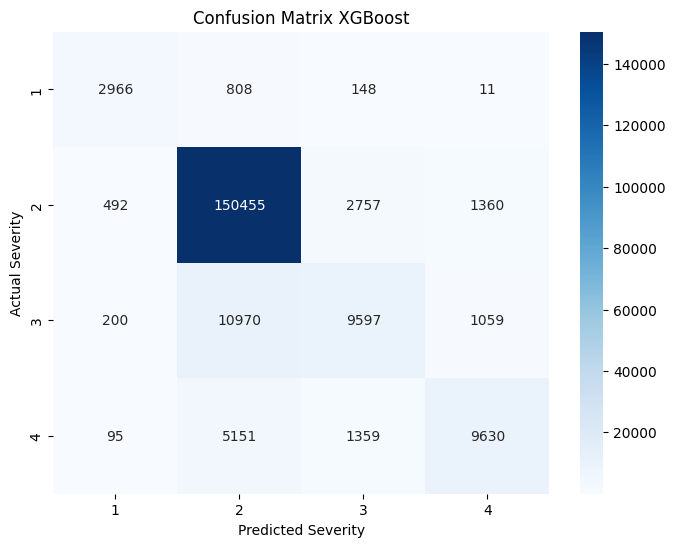

In [23]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== TAHAP 3: MODEL TRAINING DENGAN XGBOOST ===")

# XGBoost mengharuskan label dimulai dari 0. Severity asli (misal 1,2,3,4) kita mapping ke (0,1,2,3)
label_mapping = {val: i for i, val in enumerate(sorted(y_train.unique()))}
inverse_label_mapping = {i: val for val, i in label_mapping.items()}

y_train_xgb = y_train.map(label_mapping)
y_test_xgb = y_test.map(label_mapping)

# Inisialisasi Model XGBoost
model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_mapping),
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist' # Sangat cepat untuk ratusan ribu baris data
)

print("🚀 Sedang melakukan training XGBoost (tunggu sebentar)...")
# Gunakan data scaling agar seragam dengan alur preprocessing sebelumnya
model_xgb.fit(X_train_scaled, y_train_xgb)
print("✔️ Training Selesai!")

print("\n=== TAHAP 4: EVALUASI MODEL ===")
y_pred_xgb = model_xgb.predict(X_test_scaled)

# Kembalikan ke label aslinya untuk diprint di laporan
y_test_asli = y_test_xgb.map(inverse_label_mapping)
y_pred_asli = pd.Series(y_pred_xgb).map(inverse_label_mapping)

print("Classification Report:\n")
print(classification_report(y_test_asli, y_pred_asli))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_asli, y_pred_asli)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(),
            yticklabels=label_mapping.keys())
plt.title('Confusion Matrix XGBoost')
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.show()

### 🔍 Explainable AI (XAI) - Feature Importance


=== TAHAP 5: EXPLAINABLE AI (XAI) - FEATURE IMPORTANCE ===


/tmp/ipykernel_20845/2973105155.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')


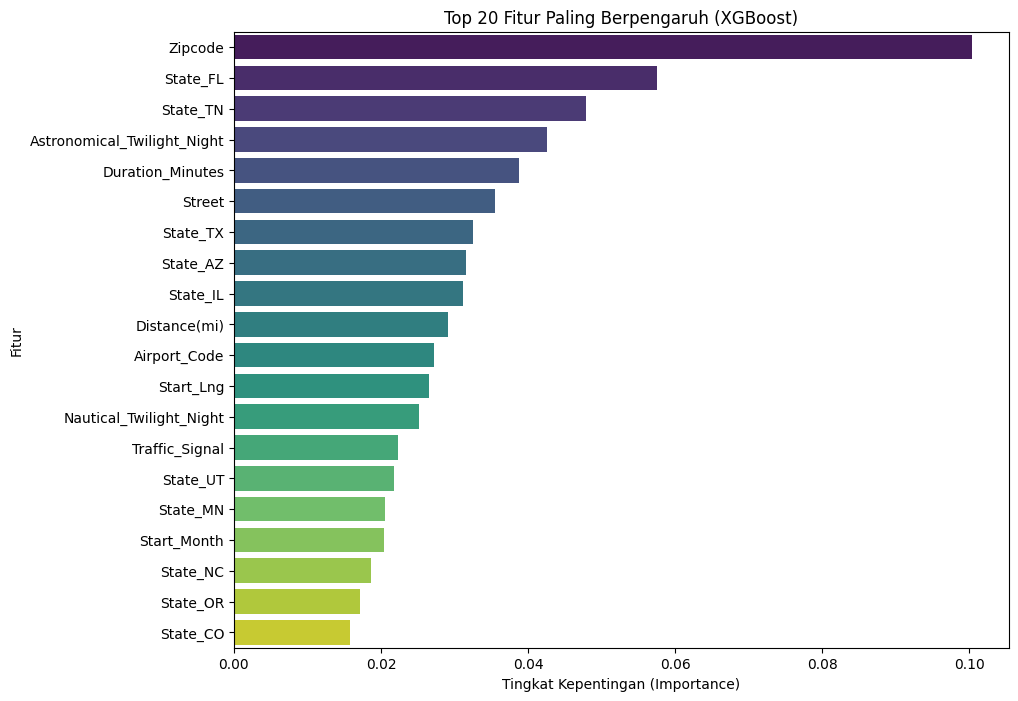

💡 Insight: Fitur-fitur di atas adalah faktor utama yang membedakan tingkat Severity kecelakaan.


In [24]:
print("=== TAHAP 5: EXPLAINABLE AI (XAI) - FEATURE IMPORTANCE ===")
# Menampilkan 20 fitur paling berpengaruh dalam pengambilan keputusan model

# Kita ekstrak feature importances dari model XGBoost
importances = model_xgb.feature_importances_

# Buat dataframe agar mudah diplot
df_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_20_features = df_importances.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')
plt.title('Top 20 Fitur Paling Berpengaruh (XGBoost)')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.show()

print("💡 Insight: Fitur-fitur di atas adalah faktor utama yang membedakan tingkat Severity kecelakaan.")

### Prediksi Data Baru


In [ ]:
import numpy as np

print("=== TAHAP 6: PREDIKSI DATA BARU ===")

# 1. Kita reset index y_test dulu jadi Series baru biar urutan barisnya (0, 1, 2...) sinkron sama X_test
y_test_reset = y_test.reset_index(drop=True)

# 2. Cari di baris ke-berapa saja (posisi integer) yang nilai Severity-nya == 4
posisi_severity = y_test_reset[y_test_reset == 2].index

if len(posisi_severity) > 0:
    # Ambil posisi baris pertama yang ketemu
    posisi_pilihan = posisi_severity[0]

    # 3. Comot dari X_test menggunakan slicing array biasa [posisi_pilihan:posisi_pilihan+1]
    # Cara ini dijamin aman mau X_test lu berupa DataFrame ataupun Array Numpy hasil PCA!
    data_baru = X_test[posisi_pilihan : posisi_pilihan + 1]

    print(f"✔️ Berhasil mengambil data baru dengan Severity {posisi_pilihan} pada posisi baris ke: {posisi_pilihan}")
else:
    print("⚠️ Waduh, kebetulan di y_test lu gak ada data yang Severity-nya 4, bro!")


print("\nData Baru yang masuk untuk diprediksi:")
# Kalau data_baru berupa array numpy, kita print langsung aray-nya biar gak error .head()
if hasattr(data_baru, 'head'):
    display(data_baru.head())
else:
    print(data_baru)

# --- LANGKAH PROSES PREDIKSI ---

# Catatan: Jika X_test lu di atas SUDAH HASIL PCA/SCALED, lu gak perlu scaler.transform lagi bro!
# Tapi kalau X_test lu masih bener-bener mentah, aktifkan baris di bawah ini:
# data_baru = scaler.transform(data_baru)

# Prediksi langsung dengan model XGBoost
prediksi_baru = model_xgb.predict(data_baru)

# Kembalikan angka prediksi ke label Severity aslinya (jika lu pakai encoding untuk target)
# Jika tidak pakai encoding target, langsung aja: hasil_severity = prediksi_baru[0]
try:
    hasil_severity = inverse_label_mapping[prediksi_baru[0]]
except NameError:
    hasil_severity = prediksi_baru[0]

print(f"\nHASIL PREDIKSI: Model menebak kecelakaan ini memiliki Severity Level -> {hasil_severity}")
print(f"FAKTA SEBENARNYA: Severity asli dari baris data ini adalah Level -> {y_test_reset.iloc[posisi_pilihan]}")

=== TAHAP 6: PREDIKSI DATA BARU ===
✔️ Berhasil mengambil data baru dengan Severity 0 pada posisi baris ke: 0

Data Baru yang masuk untuk diprediksi:


,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Street,City,County,Zipcode,Airport_Code,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Timezone_US/Eastern,Timezone_US/Mountain,Timezone_US/Pacific,Wind_Direction_Calm,Wind_Direction_E,Wind_Direction_ENE,Wind_Direction_ESE,Wind_Direction_East,Wind_Direction_N,Wind_Direction_NE,Wind_Direction_NNE,Wind_Direction_NNW,Wind_Direction_NW,Wind_Direction_North,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SSE,Wind_Direction_SSW,Wind_Direction_SW,Wind_Direction_South,Wind_Direction_VAR,Wind_Direction_Variable,Wind_Direction_W,Wind_Direction_WNW,Wind_Direction_WSW,Wind_Direction_West,Sunrise_Sunset_Night,Civil_Twilight_Night,Nautical_Twilight_Night,Astronomical_Twilight_Night,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Start_Hour,Start_Month,Day_Of_Week,Duration_Minutes
865718,37.683691,-121.053507,37.683691,-121.053507,0.0,2.024642,2.047585,2.040312,2.013794,2.039909,62.0,62.0,78.0,29.9,10.0,6.0,0.0,2.148963,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,7,9,2,73.266667



HASIL PREDIKSI: Model menebak kecelakaan ini memiliki Severity Level -> 2
FAKTA SEBENARNYA: Severity asli dari baris data ini adalah Level -> 2
